``AAPredPlot().domain()`` shows the boundary-sensitivity curve from :meth:`AAPred.predict_domain`:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Training feature matrix
sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))

# Bind df_feat so raw sequences are featurized internally by the predict_* methods
aapred = aa.AAPred(df_feat=df_feat, random_state=42)
aapred.fit(X, labels)

df_domain = aapred.predict_domain(df_seq[df_seq["entry"] == "P05067"], window=4)

The score is plotted against the boundary offset, with the best definition starred and the annotated boundary (offset 0) marked:

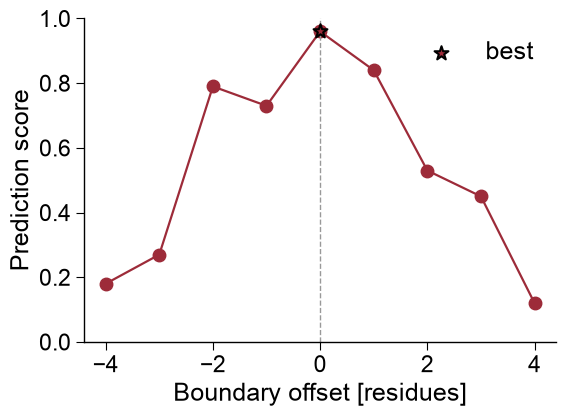

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.domain(df_domain)
plt.tight_layout()
plt.show()